# Bayer Leverkusen 2023/24 — Passing EDA

## Purpose

Explore how Bayer Leverkusen moved the ball during the 2023/24 Bundesliga season.

Initial questions include:

- How much did Leverkusen pass?
- How successful were those passes?
- Which players passed and received the ball most often?
- Where on the pitch did passes originate and end?
- How did passing vary by match and opponent?
- Which passes progressed possession?
- Which player combinations formed the strongest passing relationships?

In [27]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from leverkusen.data.loader import load_matches

TEAM_NAME = "Bayer Leverkusen"

In [28]:
matches = load_matches()

len(matches)

34

In [29]:
from leverkusen.data.transforms import build_team_event_dataset

season_passes_df = build_team_event_dataset(
    matches=matches,
    team_name=TEAM_NAME,
    event_type="Pass",
)

In [30]:
season_passes_df.shape

(24244, 142)

In [31]:
season_passes_df["match_id"].nunique()

34

In [32]:
season_passes_df["completed"] = (
    season_passes_df["pass_outcome_name"].isna()
)

season_passes_df["start_x"] = season_passes_df["location"].str[0]
season_passes_df["start_y"] = season_passes_df["location"].str[1]

season_passes_df["end_x"] = season_passes_df["pass_end_location"].str[0]
season_passes_df["end_y"] = season_passes_df["pass_end_location"].str[1]

In [33]:
print("Passes:", len(season_passes_df))
print("Matches:", season_passes_df["match_id"].nunique())
print("Players:", season_passes_df["player_name"].nunique())

Passes: 24244
Matches: 34
Players: 24


In [34]:
season_passes_df["completed"].value_counts()

completed
True     21351
False     2893
Name: count, dtype: int64

In [35]:
season_completion_pct = (
    season_passes_df["completed"].mean() * 100
)

round(season_completion_pct, 2)

np.float64(88.07)

In [36]:
season_passes_df.groupby("match_id").size().describe()

count      34.000000
mean      713.058824
std       134.759481
min       441.000000
25%       637.500000
50%       732.000000
75%       785.750000
max      1002.000000
dtype: float64

In [37]:
print(season_passes_df.shape)
print(season_passes_df["match_id"].nunique())
print(season_passes_df["completed"].value_counts())

season_completion_pct = (
    season_passes_df["completed"].mean() * 100
)

print(round(season_completion_pct, 2))

(24244, 147)
34
completed
True     21351
False     2893
Name: count, dtype: int64
88.07


In [38]:
player_pass_counts = (
    season_passes_df["player_name"]
    .value_counts()
)

player_pass_counts.head(10)

player_name
Granit Xhaka                   3299
Jonathan Tah                   2167
Alejandro Grimaldo García      2159
Exequiel Alejandro Palacios    2022
Edmond Fayçal Tapsoba          1946
Florian Wirtz                  1841
Jonas Hofmann                  1528
Robert Andrich                 1501
Piero Martín Hincapié Reyna    1423
Odilon Kossonou                1422
Name: count, dtype: int64

In [39]:
player_receive_counts = (
    season_passes_df["pass_recipient_name"]
    .value_counts()
)

player_receive_counts.head(10)

pass_recipient_name
Granit Xhaka                   3101
Florian Wirtz                  2169
Exequiel Alejandro Palacios    1905
Alejandro Grimaldo García      1890
Jonathan Tah                   1845
Edmond Fayçal Tapsoba          1661
Jonas Hofmann                  1607
Robert Andrich                 1288
Piero Martín Hincapié Reyna    1275
Jeremie Frimpong               1272
Name: count, dtype: int64

In [40]:
player_pass_summary = (
    season_passes_df
    .groupby("player_name")
    .agg(
        passes_attempted=("id", "count"),
        passes_completed=("completed", "sum"),
    )
)

player_pass_summary["completion_pct"] = (
    player_pass_summary["passes_completed"]
    / player_pass_summary["passes_attempted"]
    * 100
)

player_pass_summary = (
    player_pass_summary
    .sort_values("passes_attempted", ascending=False)
)

player_pass_summary.head(10)

,passes_attempted,passes_completed,completion_pct
player_name,,,
Granit Xhaka,3299,3045,92.300697
Jonathan Tah,2167,2057,94.923858
Alejandro Grimaldo García,2159,1783,82.584530
Exequiel Alejandro Palacios,2022,1867,92.334322
Edmond Fayçal Tapsoba,1946,1783,91.623844
Florian Wirtz,1841,1543,83.813145
Jonas Hofmann,1528,1239,81.086387
Robert Andrich,1501,1359,90.539640
Piero Martín Hincapié Reyna,1423,1314,92.340126


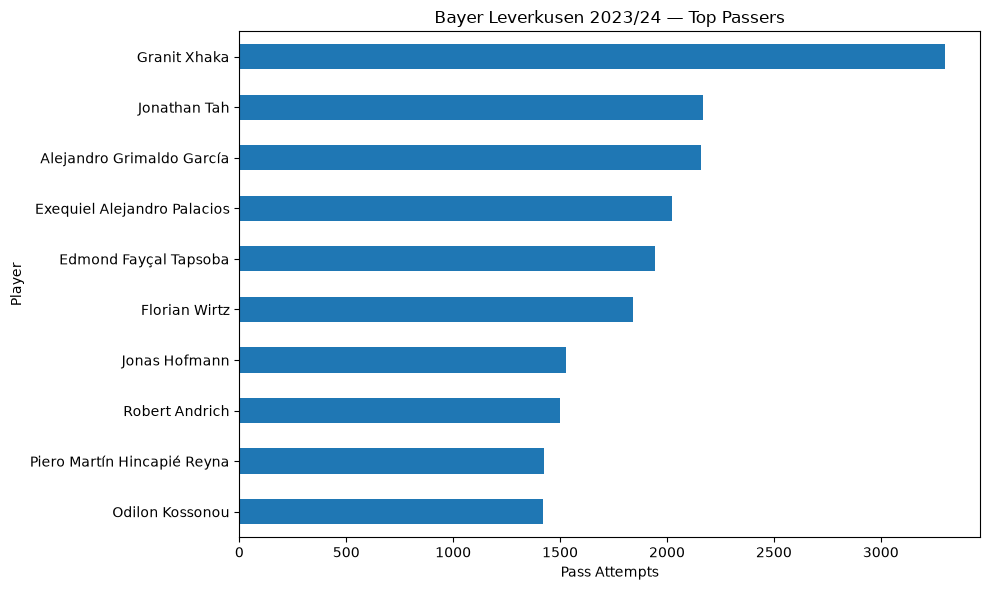

In [41]:
top_passers = player_pass_summary.head(10)

top_passers["passes_attempted"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Bayer Leverkusen 2023/24 — Top Passers")
plt.xlabel("Pass Attempts")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

In [42]:
from leverkusen.data.transforms import (
    build_team_event_dataset,
    get_team_match_context,
)

opponent_pass_frames = []

for match in matches:
    opponent_name, _ = get_team_match_context(match, TEAM_NAME)

    match_opponent_passes = build_team_event_dataset(
        matches=[match],
        team_name=opponent_name,
        event_type="Pass",
    )

    opponent_pass_frames.append(match_opponent_passes)

opponent_season_passes_df = pd.concat(
    opponent_pass_frames,
    ignore_index=True,
)

In [44]:
print("Passes:", len(opponent_season_passes_df))
print("Matches:", opponent_season_passes_df["match_id"].nunique())
print("Teams:", opponent_season_passes_df["team_name"].nunique())

Passes: 14970
Matches: 34
Teams: 17


In [45]:
opponent_season_passes_df["completed"] = (
    opponent_season_passes_df["pass_outcome_name"].isna()
)

opponent_season_passes_df["start_x"] = (
    opponent_season_passes_df["location"].str[0]
)
opponent_season_passes_df["start_y"] = (
    opponent_season_passes_df["location"].str[1]
)

opponent_season_passes_df["end_x"] = (
    opponent_season_passes_df["pass_end_location"].str[0]
)
opponent_season_passes_df["end_y"] = (
    opponent_season_passes_df["pass_end_location"].str[1]
)

In [46]:
opponent_season_completion_pct = (
    opponent_season_passes_df["completed"].mean() * 100
)

round(opponent_season_completion_pct, 2)

np.float64(80.03)